# Cluster enrichment & kinase-activity inference

This notebook interprets the temporal phosphorylation clusters biologically, using two
complementary methods. **Both are written to be defended**: each section states the
question, the exact statistic, the assumptions, how to read the result, and the honest
limitations.

1. **Cluster enrichment (Fisher's exact test).** For a chosen clustering column, test whether
   an independent per-site annotation — a predicted kinase, an ERK sequence motif, a curated
   process — is *over-represented* in a cluster beyond chance. This gives each dynamic cluster
   a biological identity.
2. **Kinase-activity inference (KSEA).** Infer each kinase's activity over the time course
   from the collective fold-change of its (predicted) substrates, per stimulation condition.

**The key non-circularity argument (state this first when you defend the enrichment).** The
clusters were built *only* from phosphorylation dynamics (the log2 fold-change time series).
The annotations tested here (kinase motif predictions, ERK motifs, curated function) never
entered the clustering. So finding that, e.g., ERK substrates concentrate in one dynamic
cluster is a genuine association between a *behaviour* (learned from data) and an *orthogonal
biological property* — not a tautology. (KSEA, separately, does not use the clusters at all.)

> Scope: developed on the WT hTERT-HME1 (`hme1_2`, TMT) dataset, but every function takes the
> columns/labels as arguments, so it transfers to the other datasets.

## 0. Setup and data preparation

We load the clustered dataset and regenerate the top-5 kinase predictions on single-localized
sites (documented fully in `kinase_prediction.ipynb`). If you have already saved a
`*_kinasepred.tsv`, load that instead to skip the ~30 s recomputation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.kinase_prediction import (
    load_uniprot_sequences,
    default_columns,
    add_kinase_windows,
    predict_top_kinases,
)
from src.cluster_enrichment import (
    kinase_membership,
    annotation_membership,
    cluster_enrichment,
    plot_enrichment_heatmap,
)
from src.kinase_activity import (
    kinase_substrate_sets,
    ksea_from_values,
    kinase_activity_profile,
    plot_activity_profiles,
)

In [2]:
DATA_PATH    = "../../notebooks/03_clustering/Data_clustered/20260715_hTERT_HEM1_2_processed_phPlus_clustered.tsv"
UNIPROT_PATH = "../../External_Data/Metadata/uniprotkb_AND_reviewed_true_AND_model_o_2026_05_13_de_compressed.tsv"

raw = pd.read_csv(DATA_PATH, sep="\t", low_memory=False,)

# Regenerate top-5 kinase predictions on single-localized sites (see kinase_prediction.ipynb).
seq_lookup  = load_uniprot_sequences(UNIPROT_PATH,)
single      = raw[raw["LocalizedNumPhos"] == 1].copy()
windows_df, _ = add_kinase_windows(single, seq_lookup, default_columns(single, "TMT"),)
predicted   = predict_top_kinases(windows_df, top_n=5,)

pred_cols = (["kinase_residue"]
             + [f"predicted_kinase_{i}" for i in range(1, 6)]
             + [f"predicted_kinase_{i}_prob" for i in range(1, 6)])
df = raw.join(predicted[pred_cols],)
print(f"dataset: {df.shape}  |  sites with a kinase prediction: {df['predicted_kinase_1'].notna().sum()}")

Scoring 4956 ser_thr substrates
Calculating percentile for 4956 ser_thr substrates
100%|██████████| 311/311 [00:03<00:00, 95.20it/s]  
                                                 
Scoring 229 tyrosine substrates
Calculating percentile for 229 tyrosine substrates
100%|██████████| 78/78 [00:00<00:00, 1693.26it/s]
                                                 
dataset: (8723, 479)  |  sites with a kinase prediction: 5185


In [3]:
# The clustering column to interpret. The dataset carries one per method:
print("cluster columns:", [c for c in df.columns if "cluster" in c.lower()])
CLUSTER_COL = "KMeans_adaptive_cluster_WT_EGF_log2_FC"

cluster columns: ['KMeans_adaptive_cluster_WT_EGF_log2_FC', 'KMeans_adaptive_cluster_WT_EGF_log2_scaled', 'KMeans_adaptive_cluster_WT_EGF_log2_zscore', 'KMeans_11_cluster_WT_EGF_log2_FC', 'KMeans_11_cluster_WT_EGF_log2_scaled', 'KMeans_11_cluster_WT_EGF_log2_zscore']


### Merging paralog kinases (manual)

Some kinases are near-identical paralogs (e.g. **ERK1/ERK2**, **MEK1/MEK2**) whose substrate
**motifs are indistinguishable** — the position-weight matrices score them almost identically,
so reporting them separately is misleading (their scores are not independent; this is exactly
the "treat a family as one signal" caveat in §2.5). Define paralog groups **manually** in
`KINASE_GROUPS` (next cell) and every analysis below — both the enrichment and the KSEA
activity — will merge them into a single entry such as `ERK1/2`.

**How the merge works, and why it is the correct one.** A group's substrate set is the
**union** of its members' predicted substrates — a site shared by both members is counted
**once**, never double-counted. KSEA is then computed on that union, so the z-score's $\sqrt{m}$
term reflects the true, de-duplicated set size. This is deliberately **not** the same as
*averaging the members' z-scores*, which would mishandle set size and double-count shared
substrates. Ungrouped kinases pass through unchanged; set `KINASE_GROUPS = {}` to disable
merging entirely.

In [10]:
# Manual paralog merges: {merged_name: [members]}. Members share a substrate motif, so they
# are pooled (union of their predicted substrates) everywhere a kinase is scored below —
# enrichment AND KSEA. Edit freely; set to {} to keep every kinase separate.
KINASE_GROUPS = {
    # "ERK1/2": ["ERK1", "ERK2"],
    # "MEK1/2": ["MEK1", "MEK2"],
    # "RAF":    ["BRAF", "RAF1"],
}

## 1. Cluster enrichment — Fisher's exact test

### 1.1 The question and the contingency table

For one cluster and one annotation category (e.g. "ERK2 is a predicted kinase of this site"),
partition the **universe** of sites four ways:

|                     | in this cluster | not in this cluster |
|---------------------|:---------------:|:-------------------:|
| **has annotation**  |       a         |         c           |
| **lacks annotation**|       b         |         d           |

The null hypothesis is that cluster membership and the annotation are **independent** — i.e.
the annotation is no more common inside the cluster than in the universe as a whole.

### 1.2 Why Fisher's exact test (not chi-square)

Fisher's exact test computes, holding the margins fixed, the exact probability of the observed
table (and more extreme ones) under independence, using the **hypergeometric distribution**:

$$P(\text{count}=a)=\frac{\binom{a+c}{a}\binom{b+d}{b}}{\binom{N}{a+b}}, \qquad N=a+b+c+d.$$

It is "exact" because it uses this discrete distribution directly rather than the chi-square
*approximation*, which is unreliable when any expected cell count is small (often the case for
a specific kinase in a small cluster). This is the same over-representation test that underlies
GO/pathway enrichment tools.

- `alternative="greater"` tests **enrichment** specifically (substrates more common in the
  cluster). It is the directional, more powerful choice when you are asking "is this cluster
  enriched?". `"two-sided"` also flags **depletion**; pick one and state it.

### 1.3 Two effect sizes (report alongside the p-value)

- **Odds ratio** $= \dfrac{a\,d}{b\,c}$ — Fisher's native effect size (>1 = enriched).
- **log2 enrichment** $= \log_2\!\dfrac{a/(a+b)}{(a+c)/N} = \log_2\dfrac{\text{observed fraction}}{\text{expected fraction}}$
  — how many fold, in log2, the annotation is over-represented vs the whole-universe rate. More
  intuitive for a figure.

A tiny p-value with a fold-enrichment near 1 is statistically detectable but biologically
trivial — always read effect size **and** significance together.

### 1.4 The universe (the single most important — and most questioned — choice)

The universe is the population the fractions are computed against. It must be the set of sites
for which the question is even defined:

- **Kinase enrichment** → universe = sites that received a prediction (single-localized, scored
  sites). A site with no prediction cannot be "an ERK2 substrate or not"; including it would
  understate the background rate and *inflate* apparent enrichment. `kinase_membership()` builds
  exactly this universe.
- **Metadata enrichment** → universe = sites where the annotation is actually assessed
  (see the ERK-motif example, which excludes an un-assessed sentinel value).

### 1.5 Multiple testing

We run (clusters x categories) tests, so raw p-values are optimistic. We control the **false
discovery rate** with Benjamini-Hochberg and report `q_value`; judge significance on `q`, not
`p`. (FDR, not family-wise correction, is the field norm here — we want few false leads among
the called hits, not zero.)

### 1.6 Kinase enrichment per cluster

Which clusters are enriched for the substrates of particular kinases? Choose a focused kinase
panel relevant to the MAPK/ERK question (edit freely).

In [11]:
ENRICH_KINASES = ["ERK1", "ERK2", "BRAF", "RAF1", "MEK1", "MEK2", "EGFR", "RSK2"] #"P90RSK", "ERK5","RSK2","P38A", "AKT1", "CDK1", "CK2A1", "GSK3B"]

kin_membership = kinase_membership(df,
                                   kinases=ENRICH_KINASES,
                                   groups=KINASE_GROUPS,   # paralogs merged (ERK1/2, MEK1/2, RAF)
                                   top_n=5,)          # a site "has" a kinase if it is in its top-5
print(f"universe (scored sites) x kinases: {kin_membership.shape}")
print(f"columns after merging: {list(kin_membership.columns)}")

kin_enrichment = cluster_enrichment(df[CLUSTER_COL],
                                    kin_membership,
                                    alternative="greater",)   # test enrichment
# strongest enrichments first
kin_enrichment.head(15)

universe (scored sites) x kinases: (5185, 8)
columns after merging: ['BRAF', 'EGFR', 'ERK1', 'ERK2', 'MEK1', 'MEK2', 'RAF1', 'RSK2']


,cluster,category,in_cluster_with,cluster_size,category_total,universe,expected,odds_ratio,log2_enrichment,p_value,q_value
0,2,RSK2,29,617,65,5185,7.734812,6.208806,1.906615,3.207939e-11,2.822986e-09
1,5,RSK2,10,65,65,5185,0.814851,16.743802,3.617321,4.890192e-09,2.151685e-07
2,2,ERK1,41,617,184,5185,21.895468,2.202615,0.904992,3.751129e-05,1.100331e-03
3,2,ERK2,50,617,261,5185,31.058245,1.820925,0.686952,3.331171e-04,7.328577e-03
4,1,ERK2,14,107,261,5185,5.386114,2.944321,1.378110,8.496289e-04,1.495347e-02
5,10,RSK2,4,55,65,5185,0.689489,6.517518,2.536401,4.752071e-03,5.974032e-02
6,1,ERK1,10,107,184,5185,3.797107,2.905558,1.397027,4.395714e-03,5.974032e-02
7,0,RAF1,82,3119,115,5185,69.177435,1.663384,0.245322,7.925511e-03,8.718062e-02
8,1,RSK2,5,107,65,5185,1.341369,4.099673,1.898222,1.054843e-02,1.031402e-01
9,7,MEK2,2,14,64,5185,0.172806,13.733871,3.532773,1.240568e-02,1.091700e-01


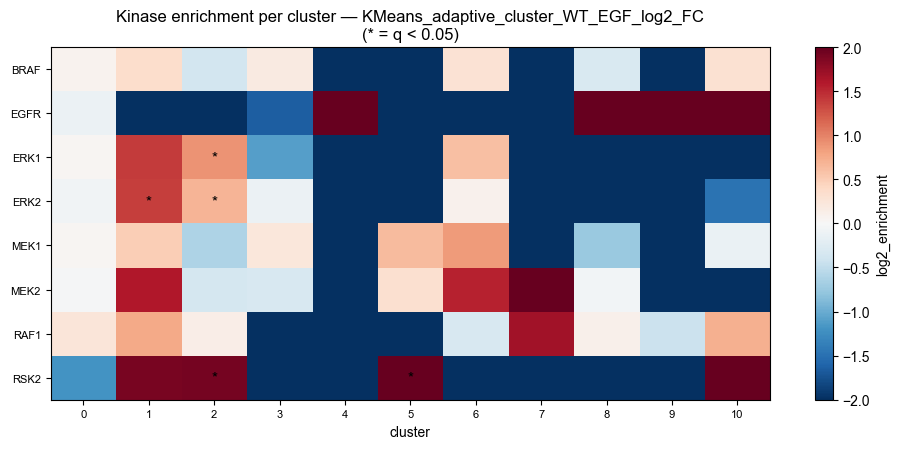

In [12]:
fig, ax = plot_enrichment_heatmap(kin_enrichment,
                                  value="log2_enrichment",
                                  clip=(-2, 2),
                                  title=f"Kinase enrichment per cluster — {CLUSTER_COL}\n(* = q < 0.05)",)
plt.show()

**How to read this, and what you may claim.** Red + a star = the cluster is significantly
enriched (q<0.05) for that kinase's predicted substrates; blue = depleted. A defensible
statement is *"cluster X is enriched for predicted ERK substrates (q=…, log2-enrichment=…),
consistent with an ERK-driven dynamic"* — a hypothesis about which kinase shapes that dynamic
class. What you may **not** claim from this alone is that those sites are physically ERK
substrates (predictions are motif-based; see §3).

### 1.7 Sequence-motif enrichment (ERK consensus)

A second, independent annotation: the PhosphoSitePlus **ERK consensus motif** flag. Two data
caveats, handled explicitly below:

- the field is stored per-peptide and can hold several `|`-joined booleans (one per site on the
  peptide) — `annotation_membership(..., multi_sep="|")` splits them and a site counts as
  motif-positive if **any** is `True`;
- an un-assessed sentinel (`"0"`) exists — we **restrict the universe** to sites actually
  scored (`True`/`False`), so "not curated" is not miscounted as "no motif".

In [7]:
erk_universe = df[df["ERK_motif"].astype(str).str.contains("True|False", na=False)]
print(f"ERK-motif universe (assessed sites): {len(erk_universe)}")

erk_membership = annotation_membership(erk_universe,
                                       annotation_col="ERK_motif",
                                       multi_sep="|",
                                       categories=["True"],   # category 'True' = has ERK motif
                                       universe="defined",)
erk_enrichment = cluster_enrichment(erk_universe[CLUSTER_COL],
                                    erk_membership,
                                    alternative="greater",)
erk_enrichment[["cluster", "in_cluster_with", "cluster_size", "category_total",
                "odds_ratio", "log2_enrichment", "q_value"]]

ERK-motif universe (assessed sites): 5594


,cluster,in_cluster_with,cluster_size,category_total,odds_ratio,log2_enrichment,q_value
0,3,542,977,2116,2.408836,0.552475,4.389692e-34
1,0,1261,3348,2116,0.983000,-0.006191,1.000000e+00
2,1,37,107,2116,0.866461,-0.129473,1.000000e+00
3,2,224,695,2116,0.755857,-0.230974,1.000000e+00
4,4,1,16,2116,0.109157,-2.597459,1.000000e+00
5,5,8,69,2116,0.212586,-1.705984,1.000000e+00
6,6,21,70,2116,0.701466,-0.334425,1.000000e+00
7,7,2,18,2116,0.204707,-1.767384,1.000000e+00
8,8,13,179,2116,0.123335,-2.380835,1.000000e+00
9,9,1,59,2116,0.027880,-4.480102,1.000000e+00


If the ERK-motif-enriched cluster(s) coincide with the ERK-kinase-enriched cluster(s) from
§1.6, that is **two independent lines of evidence** (motif match and matrix-based kinase
prediction) pointing to the same dynamic class — a much stronger statement than either alone.

## 2. Kinase-activity inference (KSEA)

### 2.1 The premise

We never measure kinase activity directly — we measure the phosphorylation of thousands of
sites. KSEA (Kinase-Substrate Enrichment Analysis; Casado et al. 2013) infers a kinase's
activity from the **collective** behaviour of its substrates: an active kinase drives its
substrate sites up, so the *mean fold-change of its substrate set*, relative to the global
average, is an activity readout. Averaging over many substrates cancels site-specific noise.
Computed at each timepoint, it becomes an activity **trajectory**.

### 2.2 The score

For kinase $K$ with $m$ substrates quantified in one condition/timepoint (one column of
log2 fold-changes vs the starve reference):

$$z_K=\frac{(\bar{s}-\bar{p})\,\sqrt{m}}{\delta}$$

- $\bar{s}$ = mean log2FC of $K$'s substrates,
- $\bar{p}$ = mean log2FC of the whole quantified population (background),
- $m$ = number of quantified substrates of $K$,
- $\delta$ = standard deviation of log2FC across the population.

It is a **z-score**: $(\bar{s}-\bar{p})$ is how far the substrate set sits above the global
mean, and $\delta/\sqrt{m}$ is the standard error of a mean of $m$ draws from a population with
spread $\delta$. So $z_K$ measures that shift in standard-error units. Large positive → the
substrate set is coordinately up far beyond chance → **inferred activation**; large negative →
inferred inhibition. A two-sided normal p-value follows from $z$, BH-corrected across kinases
per column. (This is the KSEAapp z-score formulation, Wiredja et al. 2017.)

Note the $\sqrt{m}$ term: a given mean shift is more convincing when supported by more
substrates, so bigger, consistent substrate sets earn larger |z|.

### 2.3 What the substrate set is here (state this caveat up front)

Classic KSEA uses *curated* kinase-substrate links. Here each kinase's substrate set is defined
by the **kinase_library motif prediction** (K among a site's top-N, above a percentile
threshold). This is a deliberate, statable choice — the readout is the activity of the
*motif-defined* substrate set. We use a stringent set (`min_percentile=90`, `min_substrates=5`)
to favour specificity.

In [13]:
KSEA_KINASES = ["ERK1", "ERK2", "BRAF", "RAF1", "MEK1", "MEK2", "EGFR", "RSK2"] #["ERK1", "ERK2", "ERK5", "P90RSK", "RSK2", "P70S6K","AKT1", "P38A", "CDK1", "CK2A1", "GSK3B"]
CONDITIONS   = ["EGF", "INS", "EGFnINS"]
TIMEPOINTS   = ["starve", "2", "5", "10", "15", "90"]   # omit full/starve: starve is the FC reference (=0)

activity = kinase_activity_profile(df,
                                   conditions=CONDITIONS,
                                   timepoints=TIMEPOINTS,
                                   cell_line="WT",
                                   data_type="log2:FC",
                                   kinases=KSEA_KINASES,
                                   groups=KINASE_GROUPS,  # paralogs pooled on the UNION of their substrates
                                   min_percentile=90,     # stringent substrate set
                                   min_substrates=5,)
print(f"kinases/groups scored: {sorted(activity['kinase'].unique())}")
activity.head(12)

kinases/groups scored: ['BRAF', 'EGFR', 'ERK1', 'ERK2', 'MEK1', 'MEK2', 'RAF1', 'RSK2']


,kinase,condition,timepoint,n_substrates,mean_fc,z_score,p_value,q_value
0,BRAF,EGF,starve,74,0.000000,NaN,NaN,NaN
1,EGFR,EGF,starve,10,0.000000,NaN,NaN,NaN
2,ERK1,EGF,starve,177,0.000000,NaN,NaN,NaN
3,ERK2,EGF,starve,248,0.000000,NaN,NaN,NaN
4,MEK1,EGF,starve,103,0.000000,NaN,NaN,NaN
5,MEK2,EGF,starve,63,0.000000,NaN,NaN,NaN
6,RAF1,EGF,starve,115,0.000000,NaN,NaN,NaN
7,RSK2,EGF,starve,65,0.000000,NaN,NaN,NaN
8,BRAF,EGF,2,74,0.108935,-0.479616,6.315002e-01,8.420003e-01
9,EGFR,EGF,2,10,0.828897,5.312797,1.079552e-07,8.636420e-07


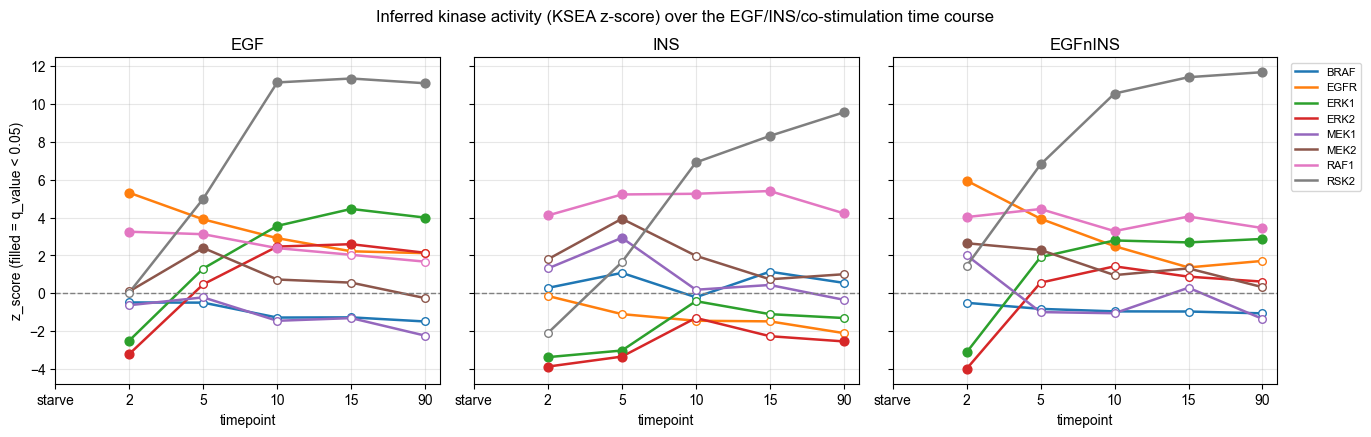

In [14]:
fig, axes = plot_activity_profiles(activity,
                                   kinases=None,   # plot every kinase/group present (merged names e.g. ERK1/2)
                                   conditions=CONDITIONS,)
fig.suptitle("Inferred kinase activity (KSEA z-score) over the EGF/INS/co-stimulation time course",
             y=1.03,)
plt.show()

### 2.4 How to read the trajectories (and defend them)

- **Sign & magnitude:** $z>0$ = substrate set up = inferred activation; filled markers pass
  q<0.05. Compare a kinase to the **zero line** (its own substrates vs the global average at
  that timepoint), and compare **conditions** side by side.
- **Sanity checks (validation against known biology):** under EGF, the ERK/RSK axis should
  activate within minutes — if your ERK trajectory rises early under EGF, that is independent
  confirmation that the motif-based substrate sets carry real signal.
- **Crosstalk (the project's core question):** compare EGF vs INS vs the EGFnINS co-stimulation.
  A kinase whose co-stimulation activity **exceeds** its EGF and INS profiles indicates
  **synergy**; one that is **blunted** indicates antagonism. This is where the multi-condition
  design pays off.

### 2.5 Honest limitations (say these before a reviewer does)

- **Motif ≠ substrate.** Predicted substrate sets lack localisation, scaffolds, and context;
  they overestimate the true substrate set and mix in non-substrates.
- **Overlapping sets → correlated scores.** Kinases in a family share motifs, so their z-scores
  are **not independent** — treat a family as one signal, not as replicate evidence.
- **Net phosphorylation ≠ kinase activity alone.** A site's log2FC also reflects phosphatase
  activity and protein-abundance changes; KSEA attributes the net change to the kinase but
  cannot prove causation.
- **log2FC is vs the starve reference**, so z reads as change relative to the serum-starved
  baseline, not absolute activity.

## 3. One-paragraph defence & references

**What these analyses establish.** (1) The dynamic clusters, though defined only by
fold-change shape, are **non-randomly associated** with orthogonal biological annotations
(specific kinase motifs, ERK consensus motifs) — quantified by Fisher's exact test with FDR
control and reported with effect sizes. (2) The **collective** phosphorylation of motif-defined
substrate sets yields **kinase-activity trajectories** (KSEA z-scores) that recover expected
signalling (e.g. EGF→ERK) and expose condition-specific crosstalk. **What they do not
establish:** physical kinase-substrate relationships or causation — both rest on *motif
predictions*, and net phosphorylation is shaped by phosphatases and abundance too. Treat every
called kinase as a **hypothesis** to be confirmed with orthogonal evidence (curated substrates,
inhibitor experiments, the mutant cell lines).

**References**
- Fisher R.A. (1922); Benjamini Y. & Hochberg Y. (1995), *JRSS-B* 57:289 — FDR.
- Casado P. et al. (2013), *Sci. Signal.* 6:rs6 — KSEA.
- Wiredja D.D., Koyutürk M., Chance M.R. (2017), *Bioinformatics* 33:3489 — KSEAapp z-score.
- Johnson J.L. et al. (2023), *Nature* 613:759 — the Ser/Thr & Tyr kinome motif matrices behind
  the substrate predictions.

**Modules:** `src/cluster_enrichment.py`, `src/kinase_activity.py` (both fully docstringed).